In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import os
if os.path.exists("checkpoints/best_model.pth"):
    os.remove("checkpoints/best_model.pth")
    print("Old checkpoint deleted")
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
from PIL import Image as PILImage
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torchvision.transforms import v2 as T

Old checkpoint deleted


1. BASIC INFO
Total rows    : 4000
Column names  : ['Image_prompt', 'Text_prompt', 'Generated_image', 'MOS_q', 'MOS_a', 'MOS_c']
  Image_prompt                              Text_prompt Generated_image  \
0        0.jpg  corgi, standing on a train track, happy  SD_0000_00.jpg   
1        0.jpg  corgi, standing on a train track, happy  SD_0000_01.jpg   
2        0.jpg  corgi, standing on a train track, happy  SD_0000_10.jpg   

    MOS_q   MOS_a   MOS_c  
0  1.7100  1.4086  3.5814  
1  2.1633  1.7220  3.8333  
2  2.2250  1.7640  4.0167  

T2I images: 2400  I2I images: 1600
Training on: 4000 images (T2I only)

2. MISSING VALUES
✅ Expected missing (structural, not a problem):
   Image_prompt: 2400 missing — normal for this dataset
✅ No unexpected missing values

3. SCORE STATISTICS
mos_quality → min:0.699  max:4.618  mean:3.134  std:0.589
mos_align   → min:0.441  max:4.810  mean:2.745  std:0.685

Normalise quality? True → divide by 4.6180
Normalise align?   True   → divide by 4.8100
Use Si

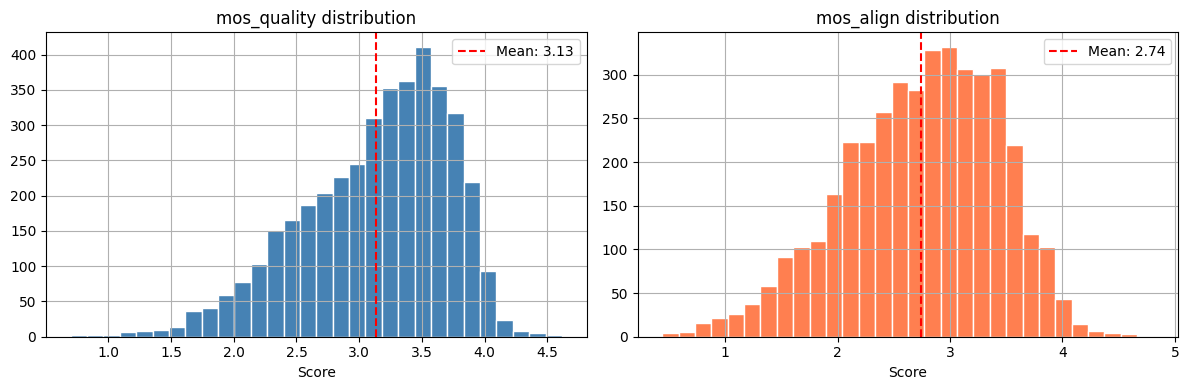

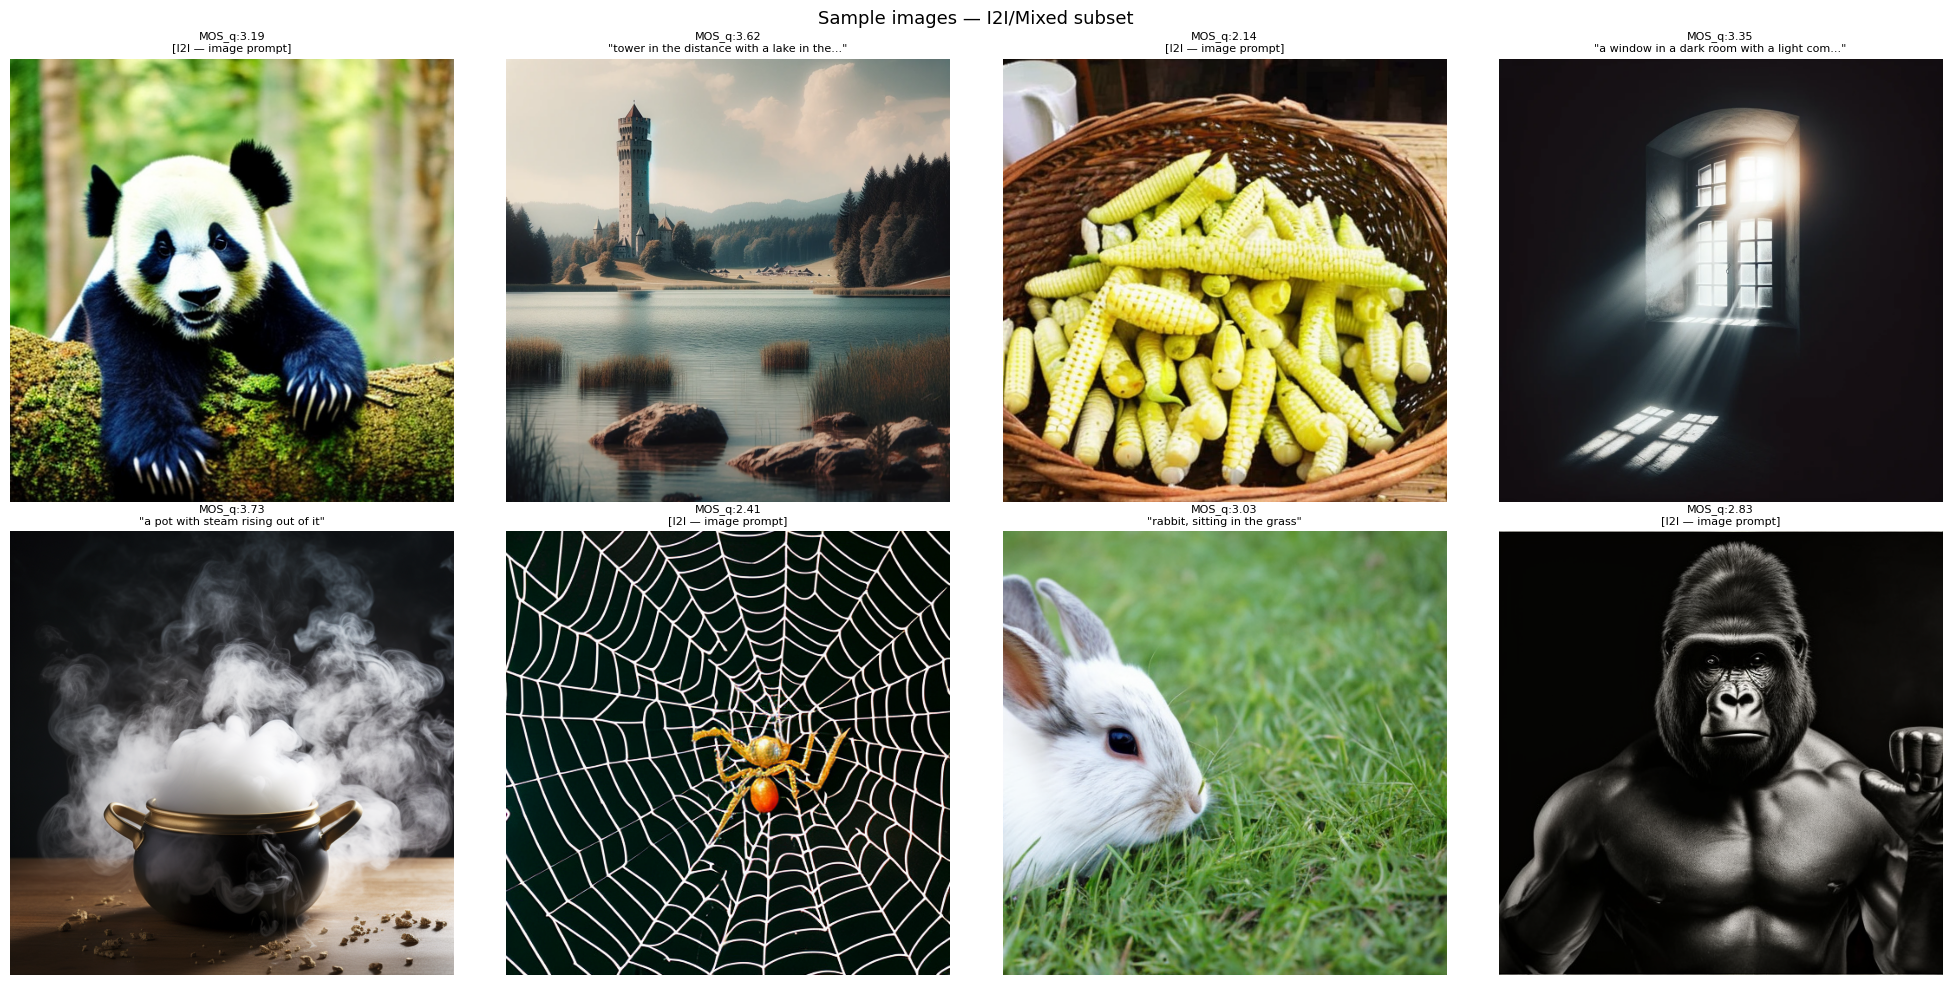


9. VARIABLES READY FOR ALL OTHER CELLS
  TRAIN_MODE       = 'quality_only'
  NUM_OUTPUTS      = 1
  TARGET_COLS      = ['MOS_q']
  NORM_FACTORS     = [np.float64(4.618)]
  USE_SIGMOID      = False
  TOTAL_IMAGES     = 4000
  MISSING_IMAGES   = 0
  SCORE_CORRELATION= 0.8573
  Q_NORM_FACTOR    = 4.6180
  A_NORM_FACTOR    = 4.8100

✅ EDA complete — run remaining cells in order


In [2]:
# ── Config ───────────────────────────────────────────────────────────────────
CSV_PATH = "data/annotation.xlsx"
IMAGE_DIR = "data/All/"

df = pd.read_excel(CSV_PATH)

# ─────────────────────────────────────────────────────────────────────────────
# 1. BASIC INFO
# ─────────────────────────────────────────────────────────────────────────────
print("="*60)
print("1. BASIC INFO")
print("="*60)
TOTAL_IMAGES = len(df)
COL_NAMES = df.columns.tolist()
print(f"Total rows    : {TOTAL_IMAGES}")
print(f"Column names  : {COL_NAMES}")
print(df.head(3))

# ─────────────────────────────────────────────────────────────────────────────
# 1b. SUBSET SELECTION
# ─────────────────────────────────────────────────────────────────────────────
df_t2i = df[df["Image_prompt"].isna()].reset_index(drop=True)   # 2400 T2I images
df_i2i = df[df["Image_prompt"].notna()].reset_index(drop=True)  # 1600 I2I images
print(f"\nT2I images: {len(df_t2i)}  I2I images: {len(df_i2i)}")

# Switch between df_t2i, df_i2i, or df
df = df
print(f"Training on: {len(df)} images (T2I only)")


# ─────────────────────────────────────────────────────────────────────────────
# 2. MISSING VALUES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("2. MISSING VALUES")
print("="*60)

# These columns are allowed to be missing — they are structurally absent
# for certain image types, not data quality issues
EXPECTED_MISSING = ["Image_prompt", "adj1", "adj2", "style"]

missing = df.isnull().sum()
real_missing = {
    col: count for col, count in missing.items()
    if count > 0 and col not in EXPECTED_MISSING
}
expected_missing = {
    col: count for col, count in missing.items()
    if count > 0 and col in EXPECTED_MISSING
}

if expected_missing:
    print(f"✅ Expected missing (structural, not a problem):")
    for col, count in expected_missing.items():
        print(f"   {col}: {count} missing — normal for this dataset")

if not real_missing:
    print(f"✅ No unexpected missing values")
else:
    print(f"⚠️  Unexpected missing values — may need attention:")
    for col, count in real_missing.items():
        print(f"   {col}: {count} missing")

MISSING_COLS = real_missing

# ─────────────────────────────────────────────────────────────────────────────
# 3. SCORE STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("3. SCORE STATISTICS")
print("="*60)

Q_MIN   = df["MOS_q"].min()
Q_MAX   = df["MOS_q"].max()
Q_MEAN  = df["MOS_q"].mean()
Q_STD   = df["MOS_q"].std()

A_MIN   = df["MOS_a"].min()
A_MAX   = df["MOS_a"].max()
A_MEAN  = df["MOS_a"].mean()
A_STD   = df["MOS_a"].std()

print(f"mos_quality → min:{Q_MIN:.3f}  max:{Q_MAX:.3f}  mean:{Q_MEAN:.3f}  std:{Q_STD:.3f}")
print(f"mos_align   → min:{A_MIN:.3f}  max:{A_MAX:.3f}  mean:{A_MEAN:.3f}  std:{A_STD:.3f}")

# Should we normalise? (if max > 1.0 then yes)
NORMALISE_QUALITY = Q_MAX > 1.0
NORMALISE_ALIGN = A_MAX > 1.0
Q_NORM_FACTOR = Q_MAX if NORMALISE_QUALITY else 1.0
A_NORM_FACTOR = A_MAX if NORMALISE_ALIGN   else 1.0

print(f"\nNormalise quality? {NORMALISE_QUALITY} → divide by {Q_NORM_FACTOR:.4f}")
print(f"Normalise align?   {NORMALISE_ALIGN}   → divide by {A_NORM_FACTOR:.4f}")

# Should we keep Sigmoid? Only if scores end up in [0,1]
USE_SIGMOID = (not NORMALISE_QUALITY)
print(f"Use Sigmoid on model output? {USE_SIGMOID}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. CORRELATION → decide how many outputs to train
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("4. SCORE CORRELATION")
print("="*60)

SCORE_CORRELATION = df["MOS_q"].corr(df["MOS_a"])
print(f"Pearson correlation: {SCORE_CORRELATION:.4f}")

if abs(SCORE_CORRELATION) > 0.8:
    TRAIN_MODE = "quality_only"    # scores too similar, no benefit training both
    NUM_OUTPUTS = 1
    TARGET_COLS = ["MOS_q"]
    NORM_FACTORS = [Q_NORM_FACTOR]
    print("⚠️  High correlation → training quality only (1 output)")
elif abs(SCORE_CORRELATION) > 0.5:
    TRAIN_MODE = "joint"
    NUM_OUTPUTS = 2
    TARGET_COLS = ["MOS_q", "mos_align"]
    NORM_FACTORS = [Q_NORM_FACTOR, A_NORM_FACTOR]
    print("ℹ️  Moderate correlation → joint training (2 outputs)")
else:
    TRAIN_MODE = "joint"
    NUM_OUTPUTS = 2
    TARGET_COLS  = ["MOS_q", "mos_align"]
    NORM_FACTORS = [Q_NORM_FACTOR, A_NORM_FACTOR]
    print("✅ Low correlation → joint training beneficial (2 outputs)")

# ─────────────────────────────────────────────────────────────────────────────
# 5. IMAGE FILE CHECK
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("5. IMAGE FILE CHECK")
print("="*60)

MISSING_IMAGES = [n for n in df["Generated_image"] if not os.path.exists(os.path.join(IMAGE_DIR, n))]
if not MISSING_IMAGES:
    print(f"✅ All {TOTAL_IMAGES} images found")
else:
    print(f"❌ {len(MISSING_IMAGES)} images missing: {MISSING_IMAGES[:5]}")
    # Remove missing images from df so training doesn't crash
    df = df[~df["name"].isin(MISSING_IMAGES)].reset_index(drop=True)
    print(f"  Removed missing entries. New size: {len(df)}")

# ─────────────────────────────────────────────────────────────────────────────
# 6. IMAGE SIZE CHECK
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("6. IMAGE SIZE CHECK")
print("="*60)

sizes = []
for name in df["Generated_image"].iloc[:20]:
    try:
        img = PILImage.open(os.path.join(IMAGE_DIR, name))
        sizes.append(img.size)
    except:
        pass

UNIQUE_SIZES = list(set(sizes))
IMAGES_ARE_SAME_SIZE = len(UNIQUE_SIZES) == 1
NATIVE_IMAGE_SIZE = UNIQUE_SIZES[0] if IMAGES_ARE_SAME_SIZE else None

print(f"Sizes found (W×H): {UNIQUE_SIZES}")
if IMAGES_ARE_SAME_SIZE:
    print(f"✅ All images are {NATIVE_IMAGE_SIZE[0]}×{NATIVE_IMAGE_SIZE[1]}")
else:
    print("ℹ️  Mixed sizes — transforms will handle this")

# ─────────────────────────────────────────────────────────────────────────────
# 7. SCORE DISTRIBUTIONS PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["MOS_q"].hist(ax=axes[0], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(Q_MEAN, color="red", linestyle="--", label=f"Mean: {Q_MEAN:.2f}")
axes[0].set_title("mos_quality distribution")
axes[0].set_xlabel("Score"); axes[0].legend()

df["MOS_a"].hist(ax=axes[1], bins=30, color="coral", edgecolor="white")
axes[1].axvline(A_MEAN, color="red", linestyle="--", label=f"Mean: {A_MEAN:.2f}")
axes[1].set_title("mos_align distribution")
axes[1].set_xlabel("Score"); axes[1].legend()
plt.tight_layout(); plt.savefig("eda_distributions.png"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 8. SAMPLE IMAGES
# ─────────────────────────────────────────────────────────────────────────────
sample = df.sample(8, random_state=42)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    try:
        img = mpimg.imread(os.path.join(IMAGE_DIR, row["Generated_image"]))
        ax.imshow(img)

        # Build score string
        scores_str = "  ".join([f"{c}:{row[c]:.2f}" for c in TARGET_COLS])

        # Add prompt if T2I (Image_prompt is NaN → it's a T2I image)
        is_t2i = pd.isna(row["Image_prompt"])
        if is_t2i and pd.notna(row.get("Text_prompt", None)):
            prompt = str(row["Text_prompt"])
            # Truncate long prompts so they fit in the title
            if len(prompt) > 40:
                prompt = prompt[:40] + "..."
            title = f"{scores_str}\n\"{prompt}\""
        else:
            title = f"{scores_str}\n[I2I — image prompt]"

        ax.set_title(title, fontsize=8, wrap=True)
    except Exception as e:
        ax.set_title(f"Error: {e}", fontsize=7)
    ax.axis("off")

plt.suptitle(
    f"Sample images — {'T2I' if is_t2i else 'I2I/Mixed'} subset",
    fontsize=13
)
plt.tight_layout()
plt.savefig("eda_samples.png")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 9. SUMMARY OF ALL VARIABLES PASSED TO OTHER CELLS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("9. VARIABLES READY FOR ALL OTHER CELLS")
print("="*60)
print(f"  TRAIN_MODE       = '{TRAIN_MODE}'")
print(f"  NUM_OUTPUTS      = {NUM_OUTPUTS}")
print(f"  TARGET_COLS      = {TARGET_COLS}")
print(f"  NORM_FACTORS     = {[round(f,4) for f in NORM_FACTORS]}")
print(f"  USE_SIGMOID      = {USE_SIGMOID}")
print(f"  TOTAL_IMAGES     = {TOTAL_IMAGES}")
print(f"  MISSING_IMAGES   = {len(MISSING_IMAGES)}")
print(f"  SCORE_CORRELATION= {SCORE_CORRELATION:.4f}")
print(f"  Q_NORM_FACTOR    = {Q_NORM_FACTOR:.4f}")
print(f"  A_NORM_FACTOR    = {A_NORM_FACTOR:.4f}")
print("\n✅ EDA complete — run remaining cells in order")

In [3]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "--pre", "torch", "torchvision", "torchaudio",
    "--index-url", "https://download.pytorch.org/whl/nightly/cu128",
    "--quiet"
])
print("done")

done


In [4]:
class AGIQADataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, preload_as_tensor=False):
        self.df            = dataframe.reset_index(drop=True)
        self.transform     = transform
        self.preload_as_tensor = preload_as_tensor

        print(f"  Pre-loading {len(self.df)} images into RAM...")
        self.images = []
        for name in self.df["Generated_image"]:
            img = PILImage.open(os.path.join(image_dir, name)).convert("RGB")
            if preload_as_tensor and self.transform:
                img = self.transform(img)   # pre-transform val/test only
            self.images.append(img)

        if preload_as_tensor:
            self.images = torch.stack(self.images)
            print(f"  Done! Tensor shape: {self.images.shape}  RAM: {self.images.nbytes/1e9:.2f} GB")
        else:
            print(f"  Done! {len(self.images)} PIL images in RAM")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = self.images[idx]
        if not self.preload_as_tensor and self.transform:
            image = self.transform(image)   # augment train on the fly each epoch
        row    = self.df.iloc[idx]
        scores = torch.tensor(
            [row[col] / norm for col, norm in zip(TARGET_COLS, NORM_FACTORS)],
            dtype=torch.float32
        )
        return image, scores


def get_transforms(image_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    train_tf = transforms.Compose([
        transforms.Resize((image_size + 32, image_size + 32)),
        transforms.RandomCrop(image_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tf, val_tf


def get_dataloaders(image_size=224, batch_size=32, val_split=0.2,
                    test_split=0.1, seed=42):
    shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    n       = len(shuffled)
    n_test  = int(n * test_split)
    n_val   = int(n * val_split)
    n_train = n - n_val - n_test

    train_df = shuffled.iloc[:n_train]
    val_df   = shuffled.iloc[n_train : n_train + n_val]
    test_df  = shuffled.iloc[n_train + n_val :]
    print(f"Split — Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

    train_tf, val_tf = get_transforms(image_size)

    train_loader = DataLoader(
    AGIQADataset(train_df, IMAGE_DIR, train_tf, preload_as_tensor=True),
        batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        AGIQADataset(val_df, IMAGE_DIR, val_tf, preload_as_tensor=True),
        batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )
    test_loader = DataLoader(
        AGIQADataset(test_df, IMAGE_DIR, val_tf, preload_as_tensor=True),
        batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )
    return train_loader, val_loader, test_loader, test_df

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class IQACNNFromScratch(nn.Module):
    def __init__(self, dropout=0.5): # increasd from 0.4
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3,   32,  pool=True),
            ConvBlock(32,  64,  pool=True),
            ConvBlock(64,  128, pool=True),
            ConvBlock(128, 256, pool=True),
            ConvBlock(256, 512, pool=True),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        # if USE_SIGMOID:
        #     head_layers.append(nn.Sigmoid())
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, NUM_OUTPUTS),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.gap(self.encoder(x)))


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params    : {total:,}")
    print(f"Trainable params: {trainable:,}")
    print(f"Outputs         : {NUM_OUTPUTS}  ({TRAIN_MODE})")
    print(f"Sigmoid         : {USE_SIGMOID}")

In [6]:
CHECKPOINT  = "checkpoints/best_model.pth"
IMAGE_SIZE  = 224
BATCH_SIZE  = 128
EPOCHS      = 150
LR          = 3e-4    # ← down from 1e-4
PATIENCE    = 25      # ← up from 15
DEVICE      = "cuda"

torch.backends.cudnn.benchmark = True 
torch.backends.cuda.matmul.allow_tf32 = True

print(f"Device: {DEVICE}")
os.makedirs("checkpoints", exist_ok=True)

train_loader, val_loader, test_loader, test_df = get_dataloaders(IMAGE_SIZE, BATCH_SIZE)

model = IQACNNFromScratch(dropout=0.4).to(DEVICE)

def combined_loss(preds, targets):
    mse_loss  = nn.MSELoss()(preds, targets)
    vx = preds   - preds.mean()
    vy = targets - targets.mean()
    plcc_loss = 1 - (vx * vy).sum() / (
        torch.sqrt((vx**2).sum() * (vy**2).sum()) + 1e-8
    )
    return mse_loss + 0.5 * plcc_loss

criterion = combined_loss
# criterion = combined_loss
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

count_parameters(model)

Device: cuda
Split — Train: 2800  Val: 800  Test: 400
  Pre-loading 2800 images into RAM...
  Done! Tensor shape: torch.Size([2800, 3, 224, 224])  RAM: 1.69 GB
  Pre-loading 800 images into RAM...
  Done! Tensor shape: torch.Size([800, 3, 224, 224])  RAM: 0.48 GB
  Pre-loading 400 images into RAM...
  Done! Tensor shape: torch.Size([400, 3, 224, 224])  RAM: 0.24 GB
Total params    : 1,733,921
Trainable params: 1,733,921
Outputs         : 1  (quality_only)
Sigmoid         : False


In [7]:
from torch.amp import autocast, GradScaler

scaler           = GradScaler()
history          = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_val_loss    = float("inf")
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for images, scores in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        images, scores = images.to(DEVICE), scores.to(DEVICE)
        # ← NO gpu_augment here
        optimizer.zero_grad()
        with autocast(device_type="cuda"):
            preds = model(images)
            loss  = criterion(preds, scores)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        train_losses.append(loss.item())

    model.eval()
    val_losses, val_rmses = [], []
    with torch.no_grad():
        for images, scores in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]  "):
            images, scores = images.to(DEVICE), scores.to(DEVICE)
            with autocast(device_type="cuda"):
                preds = model(images)
            val_losses.append(criterion(preds, scores).item())
            val_rmses.append(torch.sqrt(criterion(preds, scores)).item())

    train_loss = np.mean(train_losses)
    val_loss   = np.mean(val_losses)
    val_rmse   = np.mean(val_rmses)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_rmse"].append(val_rmse)
    scheduler.step()

    print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val RMSE: {val_rmse:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            "epoch":           epoch,
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss":        val_loss,
        }, CHECKPOINT)
        print(f"  ✅ Saved new best model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  🛑 Early stopping at epoch {epoch}")
            break

print("Training complete!")

Epoch 1/150 [val]  : 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]


Epoch   1 | Train Loss: 1.2072 | Val Loss: 0.3814 | Val RMSE: 0.6163 | LR: 3.00e-04
  ✅ Saved new best model (val_loss=0.3814)


Epoch 2/150 [val]  : 100%|██████████| 7/7 [00:00<00:00, 37.18it/s]


Epoch   2 | Train Loss: 0.5694 | Val Loss: 0.2999 | Val RMSE: 0.5462 | LR: 3.00e-04
  ✅ Saved new best model (val_loss=0.2999)


Epoch 3/150 [val]  : 100%|██████████| 7/7 [00:00<00:00, 37.73it/s]


...

Epoch  74 | Train Loss: 0.0535 | Val Loss: 0.2304 | Val RMSE: 0.4797 | LR: 1.58e-04
  No improvement (23/25)


Epoch 75/150 [val]  : 100%|██████████| 7/7 [00:00<00:00, 38.44it/s]


Epoch  75 | Train Loss: 0.0551 | Val Loss: 0.2891 | Val RMSE: 0.5364 | LR: 1.55e-04
  No improvement (24/25)


Epoch 76/150 [val]  : 100%|██████████| 7/7 [00:00<00:00, 37.47it/s]

Epoch  76 | Train Loss: 0.0556 | Val Loss: 0.2308 | Val RMSE: 0.4800 | LR: 1.52e-04
  No improvement (25/25)
  🛑 Early stopping at epoch 76
Training complete!


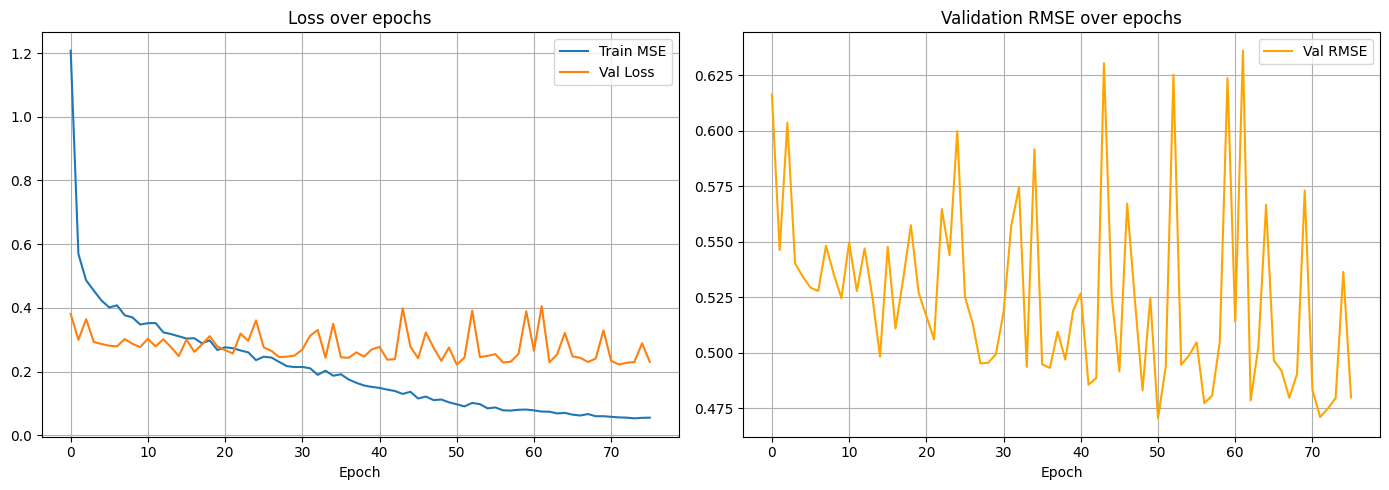

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history["train_loss"], label="Train MSE")
ax1.plot(history["val_loss"],   label="Val Loss")
ax1.set_title("Loss over epochs"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True)

ax2.plot(history["val_rmse"], color="orange", label="Val RMSE")
ax2.set_title("Validation RMSE over epochs"); ax2.set_xlabel("Epoch")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

Evaluating: 100%|██████████| 4/4 [00:04<00:00,  1.08s/it]


── Mos_q (original scale 0–4.62) ──
  RMSE: 0.5383  (lower is better)
  PLCC: 0.5158  (higher is better, max 1.0)
  SRCC: 0.5218  (higher is better, max 1.0)


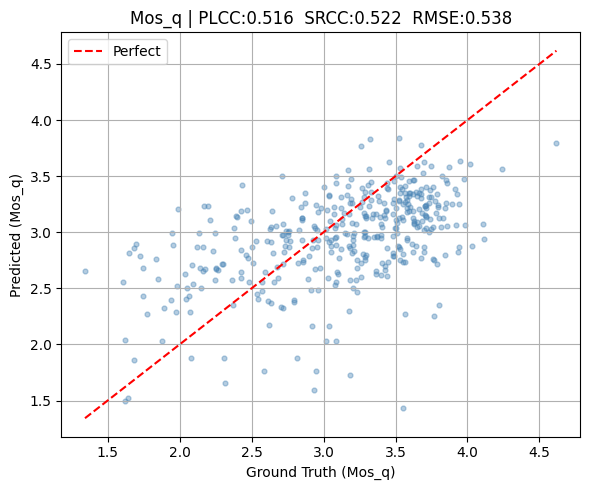

In [9]:
model.eval()
all_preds, all_gt = [], []
with torch.no_grad():
    for images, scores in tqdm(test_loader, desc="Evaluating"):
        preds = model(images.to(DEVICE)).cpu().numpy()
        all_preds.append(preds)
        all_gt.append(scores.numpy())

preds_arr = np.concatenate(all_preds, axis=0)
gt_arr = np.concatenate(all_gt,    axis=0)

# ← TARGET_COLS and NORM_FACTORS from EDA
score_labels = [c.replace("mos_", "").capitalize() for c in TARGET_COLS]

for i, label in enumerate(score_labels):
    # Denormalise back to original scale for interpretable MAE/MSE
    gt_orig = gt_arr[:, i]    * NORM_FACTORS[i]
    pred_orig = preds_arr[:, i] * NORM_FACTORS[i]

    rmse = np.sqrt(mean_squared_error(gt_orig, pred_orig))
    plcc, _ = pearsonr(gt_orig, pred_orig)
    srcc, _ = spearmanr(gt_orig, pred_orig)

    print(f"\n── {label} (original scale 0–{NORM_FACTORS[i]:.2f}) ──")
    print(f"  RMSE: {rmse:.4f}  (lower is better)")
    print(f"  PLCC: {plcc:.4f}  (higher is better, max 1.0)")
    print(f"  SRCC: {srcc:.4f}  (higher is better, max 1.0)")

# Scatter plot
fig, axes = plt.subplots(1, NUM_OUTPUTS, figsize=(6 * NUM_OUTPUTS, 5))
if NUM_OUTPUTS == 1:
    axes = [axes]
for i, (ax, label) in enumerate(zip(axes, score_labels)):
    gt_orig = gt_arr[:, i]    * NORM_FACTORS[i]
    pred_orig = preds_arr[:, i] * NORM_FACTORS[i]
    plcc, _ = pearsonr(gt_orig, pred_orig)
    srcc, _ = spearmanr(gt_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(gt_orig, pred_orig))
    ax.scatter(gt_orig, pred_orig, alpha=0.4, s=12, color="steelblue")
    mn, mx = gt_orig.min(), gt_orig.max()
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect")
    ax.set_xlabel(f"Ground Truth ({label})")
    ax.set_ylabel(f"Predicted ({label})")
    ax.set_title(f"{label} | PLCC:{plcc:.3f}  SRCC:{srcc:.3f}  RMSE:{rmse:.3f}")
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("evaluation_scatter.png")
plt.show()

In [10]:
def predict_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    image  = PILImage.open(img_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(tensor).squeeze().cpu().numpy()

    # ← denormalise back to original scale using EDA NORM_FACTORS
    if NUM_OUTPUTS == 1:
        pred = [pred]
    result = {col: round(float(p) * norm, 4)
              for col, p, norm in zip(TARGET_COLS, pred, NORM_FACTORS)}
    return result

# Example
result = predict_image("data/All/SD_0000_00.jpg")
print(result)

{'MOS_q': np.float64(2.8227)}
